<a href="https://colab.research.google.com/github/Lord3739/Data-Analytics2/blob/main/MARCCAPSTONEP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Air Quality and Health Impacts


In [37]:
URL = "https://data.cityofnewyork.us/Environment/Air-Quality-and-Health-Impacts/c3uy-2p5r/about_data"

## DATA LOADING

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Air_Quality_and_Health_Impacts_20260416.csv")

In [39]:
df

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,877071,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,306308,Chelsea-Village,Summer 2023,06/01/2023,20.932670,NaN
1,877185,375,Nitrogen dioxide (NO2),Mean,ppb,CD,308,Crown Heights and Prospect Heights (CD8),Summer 2023,06/01/2023,11.870839,NaN
2,877080,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,501502,Northern SI,Summer 2023,06/01/2023,12.522830,NaN
3,876849,375,Nitrogen dioxide (NO2),Mean,ppb,Borough,2,Brooklyn,Summer 2023,06/01/2023,12.522216,NaN
4,874599,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Summer 2023,06/01/2023,9.288254,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18857,151661,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,501,Port Richmond,2005,01/01/2005,17.626961,NaN
18858,151637,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,208,Canarsie - Flatlands,2005,01/01/2005,35.691447,NaN
18859,131023,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",Borough,2,Brooklyn,2005-2007,01/01/2005,5.600000,NaN
18860,131131,655,Asthma hospitalizations due to Ozone,Estimated annual rate (under age 18),"per 100,000 children",UHF42,202,Downtown - Heights - Slope,2005-2007,01/01/2005,16.500000,NaN


## DATA EXPLORATION

In [40]:
# Let's look at the Shape of the data
print(df.shape)

(18862, 12)


In [41]:
## Let's look at the name of the columns
df.columns

Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

In [42]:
## Let's look at the infos in the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [43]:
# Let's explore the data more
print(df.info)

<bound method DataFrame.info of        Unique ID  Indicator ID                                         Name  \
0         877071           375                       Nitrogen dioxide (NO2)   
1         877185           375                       Nitrogen dioxide (NO2)   
2         877080           375                       Nitrogen dioxide (NO2)   
3         876849           375                       Nitrogen dioxide (NO2)   
4         874599           365                      Fine particles (PM 2.5)   
...          ...           ...                                          ...   
18857     151661           643                Annual vehicle miles traveled   
18858     151637           643                Annual vehicle miles traveled   
18859     131023           652  Cardiac and respiratory deaths due to Ozone   
18860     131131           655         Asthma hospitalizations due to Ozone   
18861     131327           661         Asthma hospitalizations due to Ozone   

                   

<Axes: >

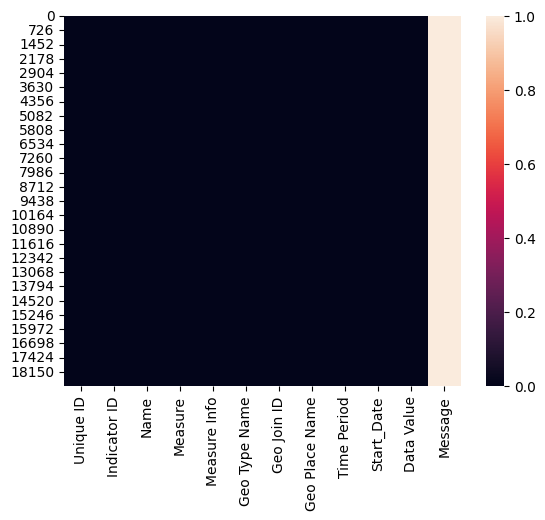

In [44]:
# lets look at the null values columns
sns.heatmap(df.isnull())

In [45]:
# lets check the missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Start_Date            0
Data Value            0
Message           18862
dtype: int64


In [46]:
# Statistical summaries of all numerical columns
print(df.describe())

           Unique ID  Indicator ID   Geo Join ID    Data Value  Message
count   18862.000000  18862.000000  1.886200e+04  18862.000000      0.0
mean   452004.167533    431.817888  5.983262e+05     21.051580      NaN
std    262910.731230    113.946565  7.819721e+06     23.564920      NaN
min    130355.000000    365.000000  1.000000e+00      0.000000      NaN
25%    176073.250000    365.000000  2.020000e+02      8.742004      NaN
50%    412490.500000    375.000000  3.030000e+02     14.790000      NaN
75%    669588.750000    386.000000  4.040000e+02     26.267500      NaN
max    878254.000000    661.000000  1.051061e+08    424.700000      NaN


### DATA TRANSFORMATION

LET'S DELETE THE MESSAGE COLUMN

In [47]:
# Let's create a new dataframe without "Message"
df.drop("Message", axis=1, inplace=True)

In [48]:
df

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value
0,877071,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,306308,Chelsea-Village,Summer 2023,06/01/2023,20.932670
1,877185,375,Nitrogen dioxide (NO2),Mean,ppb,CD,308,Crown Heights and Prospect Heights (CD8),Summer 2023,06/01/2023,11.870839
2,877080,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,501502,Northern SI,Summer 2023,06/01/2023,12.522830
3,876849,375,Nitrogen dioxide (NO2),Mean,ppb,Borough,2,Brooklyn,Summer 2023,06/01/2023,12.522216
4,874599,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Summer 2023,06/01/2023,9.288254
...,...,...,...,...,...,...,...,...,...,...,...
18857,151661,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,501,Port Richmond,2005,01/01/2005,17.626961
18858,151637,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,208,Canarsie - Flatlands,2005,01/01/2005,35.691447
18859,131023,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",Borough,2,Brooklyn,2005-2007,01/01/2005,5.600000
18860,131131,655,Asthma hospitalizations due to Ozone,Estimated annual rate (under age 18),"per 100,000 children",UHF42,202,Downtown - Heights - Slope,2005-2007,01/01/2005,16.500000


In [49]:
# Let's see what Geo Place Name we have
print(df["Geo Place Name"].unique())

['Chelsea-Village' 'Crown Heights and Prospect Heights (CD8)'
 'Northern SI' 'Brooklyn' 'Highbridge and Concourse (CD4)'
 'Woodside and Sunnyside (CD2)' 'Park Slope and Carroll Gardens (CD6)'
 'Washington Heights and Inwood (CD12)' 'Downtown - Heights - Slope'
 'Canarsie - Flatlands' 'Jamaica' 'Bayside Little Neck-Fresh Meadows'
 'Upper West Side' 'Union Square - Lower East Side'
 'Jamaica and Hollis (CD12)' 'Bensonhurst (CD11)' 'Northeast Bronx'
 'Fresh Meadows' 'Crotona -Tremont'
 'Morningside Heights and Hamilton Heights (CD9)' 'Stapleton - St. George'
 'Morris Park and Bronxdale (CD11)' 'Coney Island (CD13)'
 'Union Square-Lower Manhattan' 'Bedford Stuyvesant - Crown Heights'
 'West Queens' 'Rockaways' 'Borough Park' 'Bensonhurst - Bay Ridge'
 'Central Harlem - Morningside Heights' 'Greenwich Village and Soho (CD2)'
 'Upper East Side (CD8)' 'Parkchester and Soundview (CD9)'
 'Bayside and Little Neck (CD11)' 'Kingsbridge - Riverdale'
 'Ridgewood and Maspeth (CD5)' 'Sunset Park'
 'Re

In [51]:
# Let's see what pollutants we have
print(df["Name"].unique())

['Nitrogen dioxide (NO2)' 'Fine particles (PM 2.5)' 'Ozone (O3)'
 'Annual vehicle miles traveled (trucks)'
 'Annual vehicle miles traveled (cars)' 'Annual vehicle miles traveled'
 'Deaths due to PM2.5' 'Asthma emergency department visits due to PM2.5'
 'Asthma emergency departments visits due to Ozone'
 'Asthma hospitalizations due to Ozone'
 'Cardiac and respiratory deaths due to Ozone'
 'Cardiovascular hospitalizations due to PM2.5 (age 40+)'
 'Respiratory hospitalizations due to PM2.5 (age 20+)'
 'Boiler Emissions- Total SO2 Emissions'
 'Boiler Emissions- Total NOx Emissions'
 'Boiler Emissions- Total PM2.5 Emissions' 'Outdoor Air Toxics - Benzene'
 'Outdoor Air Toxics - Formaldehyde']


In [52]:
# Let's see what time periods we have
print(df["Time Period"].unique())

['Summer 2023' 'Annual Average 2023' 'Winter 2022-23' 'Summer 2022'
 'Annual Average 2022' 'Winter 2021-22' 'Summer 2021'
 'Annual Average 2021' 'Winter 2020-21' 'Summer 2020'
 'Annual Average 2020' 'Winter 2019-20' 'Summer 2019' '2019'
 'Annual Average 2019' 'Winter 2018-19' 'Summer 2018'
 'Annual Average 2018' 'Winter 2017-18' 'Summer 2017'
 'Annual Average 2017' '2017-2019' 'Winter 2016-17' 'Summer 2016'
 'Annual Average 2016' 'Winter 2015-16' 'Summer 2015' '2015-2017'
 'Annual Average 2015' '2015' 'Winter 2014-15' 'Summer 2014' '2014'
 'Annual Average 2014' 'Winter 2013-14' 'Summer 2013' '2013'
 'Annual Average 2013' 'Winter 2012-13' 'Summer 2012' '2012-2014'
 'Winter 2011-12' 'Annual Average 2012' 'Summer 2011' '2011'
 'Annual Average 2011' 'Winter 2010-11' 'Summer 2010' '2010'
 'Annual Average 2010' 'Winter 2009-10' 'Summer 2009' '2009-2011'
 'Winter 2008-09' 'Annual Average 2009' '2005' '2005-2007']


In [55]:
# Let's add a new column
df["Value_Category"] = pd.cut(
    df["Data Value"],
    bins=[0, 5, 10, 20, float("inf")],
    labels=["Very Low", "Low", "Medium", "High"]
)

In [54]:
# Let's look at the new data
df

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Value_Category
0,877071,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,306308,Chelsea-Village,Summer 2023,06/01/2023,20.932670,High
1,877185,375,Nitrogen dioxide (NO2),Mean,ppb,CD,308,Crown Heights and Prospect Heights (CD8),Summer 2023,06/01/2023,11.870839,Medium
2,877080,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,501502,Northern SI,Summer 2023,06/01/2023,12.522830,Medium
3,876849,375,Nitrogen dioxide (NO2),Mean,ppb,Borough,2,Brooklyn,Summer 2023,06/01/2023,12.522216,Medium
4,874599,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Summer 2023,06/01/2023,9.288254,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
18857,151661,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,501,Port Richmond,2005,01/01/2005,17.626961,Medium
18858,151637,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,208,Canarsie - Flatlands,2005,01/01/2005,35.691447,High
18859,131023,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",Borough,2,Brooklyn,2005-2007,01/01/2005,5.600000,Low
18860,131131,655,Asthma hospitalizations due to Ozone,Estimated annual rate (under age 18),"per 100,000 children",UHF42,202,Downtown - Heights - Slope,2005-2007,01/01/2005,16.500000,Medium


In [56]:
# Let's create a season colomn

def extract_season(time_period):
    if pd.isna(time_period):
        return "Unknown"
    if "Summer" in str(time_period):
        return "Summer"
    elif "Winter" in str(time_period):
        return "Winter"
    elif "Spring" in str(time_period):
        return "Spring"
    elif "Fall" in str(time_period) or "Autumn" in str(time_period):
        return "Fall"
    else:
        return "Unknown"

df["Season"] = df["Time Period"].apply(extract_season)

# Let's check what seasons were found
print(df["Season"].value_counts())

Season
Unknown    8287
Summer     6345
Winter     4230
Name: count, dtype: int64


In [57]:
df

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Value_Category,Season
0,877071,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,306308,Chelsea-Village,Summer 2023,06/01/2023,20.932670,High,Summer
1,877185,375,Nitrogen dioxide (NO2),Mean,ppb,CD,308,Crown Heights and Prospect Heights (CD8),Summer 2023,06/01/2023,11.870839,Medium,Summer
2,877080,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,501502,Northern SI,Summer 2023,06/01/2023,12.522830,Medium,Summer
3,876849,375,Nitrogen dioxide (NO2),Mean,ppb,Borough,2,Brooklyn,Summer 2023,06/01/2023,12.522216,Medium,Summer
4,874599,365,Fine particles (PM 2.5),Mean,mcg/m3,CD,204,Highbridge and Concourse (CD4),Summer 2023,06/01/2023,9.288254,Low,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18857,151661,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,501,Port Richmond,2005,01/01/2005,17.626961,Medium,Unknown
18858,151637,643,Annual vehicle miles traveled,Million miles,per square mile,UHF42,208,Canarsie - Flatlands,2005,01/01/2005,35.691447,High,Unknown
18859,131023,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",Borough,2,Brooklyn,2005-2007,01/01/2005,5.600000,Low,Unknown
18860,131131,655,Asthma hospitalizations due to Ozone,Estimated annual rate (under age 18),"per 100,000 children",UHF42,202,Downtown - Heights - Slope,2005-2007,01/01/2005,16.500000,Medium,Unknown


## ANALYSIS

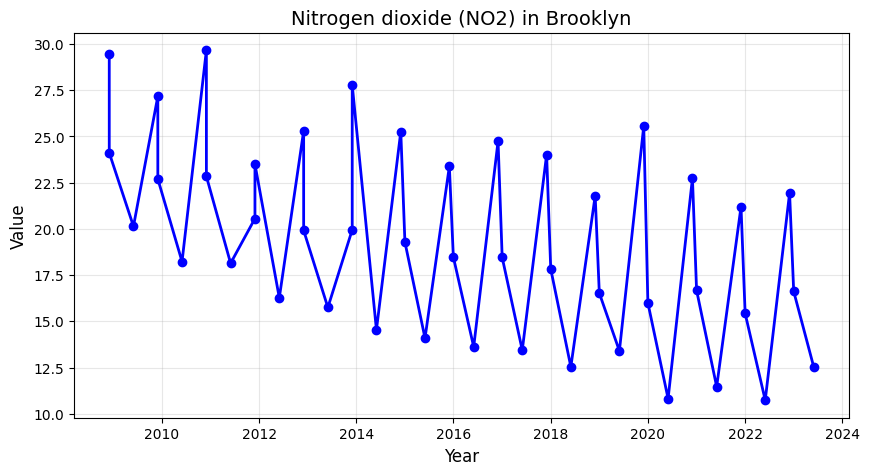

   Quick Summary:
 Earliest: 12.52
 Latest: 29.43
 Average: 19.43


In [58]:
# let's convert the dates
df["Start_Date"] = pd.to_datetime(df["Start_Date"])

#  analyze
pollutant = "Nitrogen dioxide (NO2)"
location = "Brooklyn"

# Let's filter data
trend_data = df[(df["Name"] == pollutant) & (df["Geo Place Name"] == location)]

# Let's plot the chart
plt.figure(figsize=(10, 5))
plt.plot(trend_data["Start_Date"], trend_data["Data Value"], marker="o", color="blue", linewidth=2)
plt.title(f"{pollutant} in {location}", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Stats
print(f"   Quick Summary:")
print(f" Earliest: {trend_data['Data Value'].iloc[0]:.2f}")
print(f" Latest: {trend_data['Data Value'].iloc[-1]:.2f}")
print(f" Average: {trend_data['Data Value'].mean():.2f}")

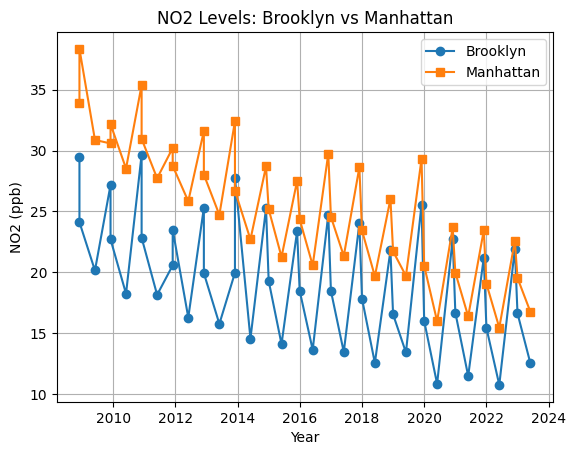

In [59]:
# let's compare data for two places
brooklyn = df[(df["Name"] == "Nitrogen dioxide (NO2)") & (df["Geo Place Name"] == "Brooklyn")]
manhattan = df[(df["Name"] == "Nitrogen dioxide (NO2)") & (df["Geo Place Name"] == "Manhattan")]

# Let's plot both on same graph
plt.plot(brooklyn["Start_Date"], brooklyn["Data Value"], marker="o", label="Brooklyn")
plt.plot(manhattan["Start_Date"], manhattan["Data Value"], marker="s", label="Manhattan")
plt.title("NO2 Levels: Brooklyn vs Manhattan")
plt.xlabel("Year")
plt.ylabel("NO2 (ppb)")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# Let's find neighborhoods with worst NO2 pollution
worst_no2 = df[df["Name"] == "Nitrogen dioxide (NO2)"].groupby("Geo Place Name")["Data Value"].mean().sort_values(ascending=False).head(10)

print(" Top 10 neighborhoods with worst NO2 pollution:")
print(worst_no2)

 Top 10 neighborhoods with worst NO2 pollution:
Geo Place Name
Midtown (CD5)                           33.954114
Gramercy Park - Murray Hill             31.658060
Chelsea - Clinton                       29.978237
Stuyvesant Town and Turtle Bay (CD6)    29.479491
Chelsea-Village                         28.928614
Upper East Side-Gramercy                28.536984
Clinton and Chelsea (CD4)               27.874427
Financial District (CD1)                27.615449
Lower Manhattan                         27.528720
Greenwich Village - SoHo                26.843446
Name: Data Value, dtype: float64


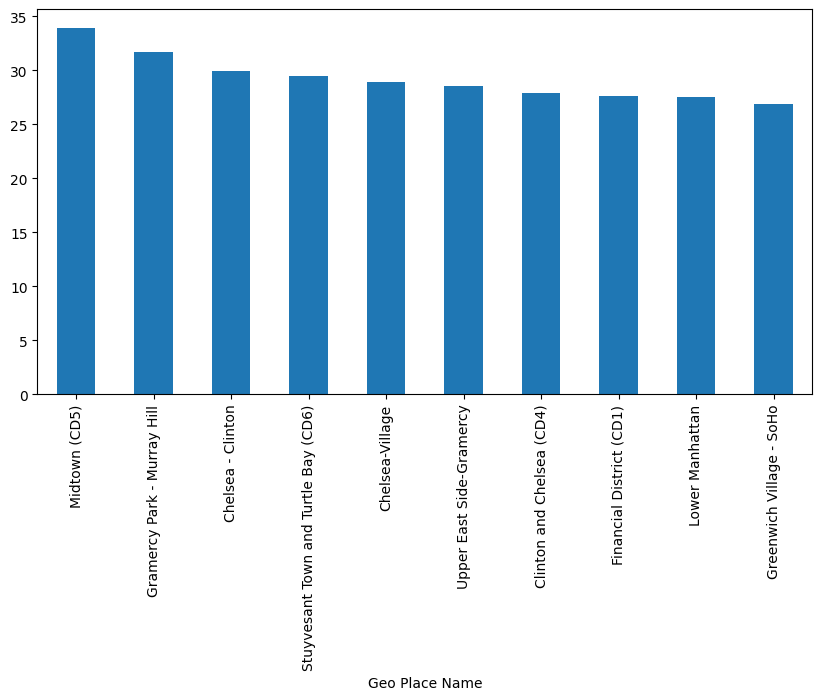

In [61]:
worst_no2.plot(kind = "bar", figsize = (10,5));

In [62]:
# Let's find neighborhoods with worst Fine particles pollution
worst_pm = df[df["Name"] == "Fine particles (PM 2.5)"].groupby("Geo Place Name")["Data Value"].mean().sort_values(ascending=False).head(10)

print(" Top 10 neighborhoods with worst Fine particles pollution:")
print(worst_pm)

 Top 10 neighborhoods with worst Fine particles pollution:
Geo Place Name
Midtown (CD5)                           12.787937
Gramercy Park - Murray Hill             11.855280
Chelsea - Clinton                       11.565241
Chelsea-Village                         11.262609
Stuyvesant Town and Turtle Bay (CD6)    11.198305
Upper East Side-Gramercy                10.960357
Clinton and Chelsea (CD4)               10.850420
Greenwich Village and Soho (CD2)        10.788380
Greenwich Village - SoHo                10.662813
Financial District (CD1)                10.532419
Name: Data Value, dtype: float64


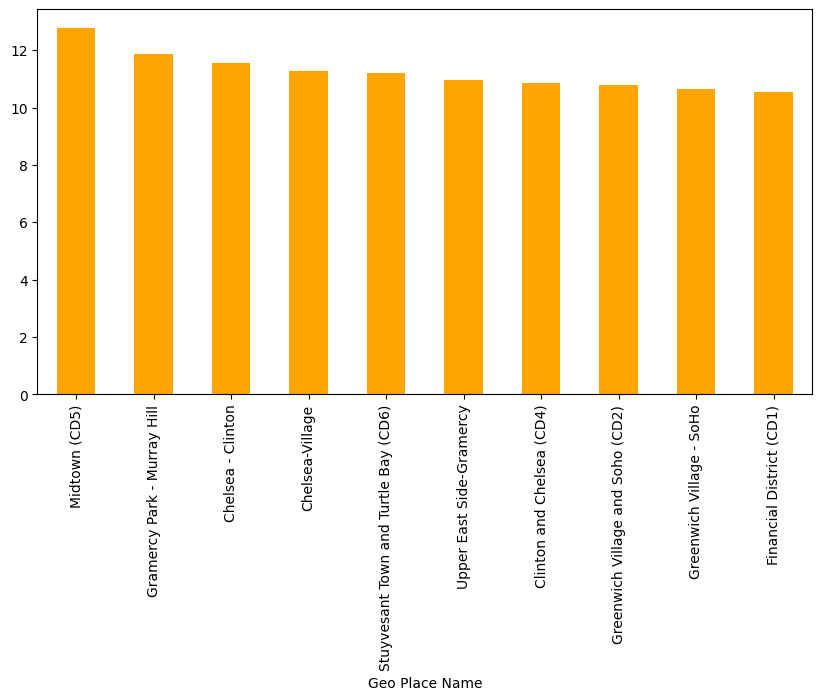

In [63]:
worst_pm.plot(kind = "bar", color = 'orange', figsize = (10,5));

In [64]:
# Let's check the Averge NO2 by season
pollutant = "Nitrogen dioxide (NO2)"

# Let's filter and group by season
seasonal_data = df[df["Name"] == pollutant].groupby("Season")["Data Value"].mean()

print(f" Average {pollutant} by season:")
print(seasonal_data)

# Let's find which season is worst
worst_season = seasonal_data.idxmax()
worst_value = seasonal_data.max()
print(f" Worst season: {worst_season} ({worst_value:.2f})")

 Average Nitrogen dioxide (NO2) by season:
Season
Summer     15.983314
Unknown    20.020016
Winter     25.172254
Name: Data Value, dtype: float64
 Worst season: Winter (25.17)


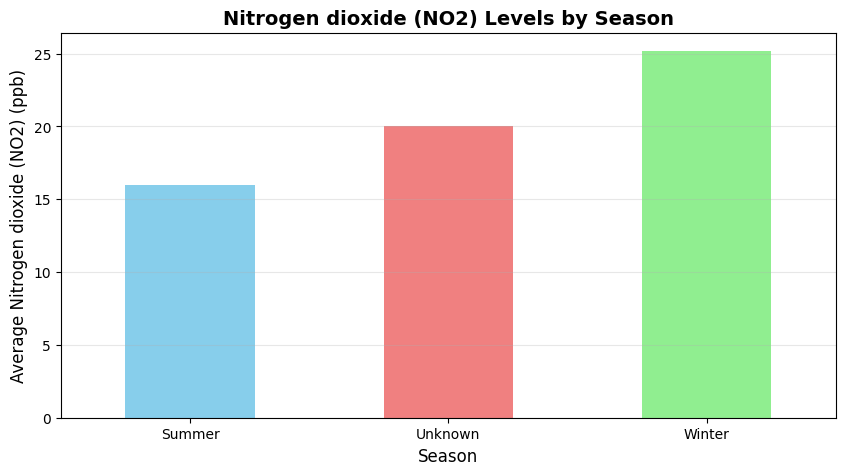

In [65]:
# NO2 LEVELS BY SEASON
plt.figure(figsize=(10, 5))
seasonal_data.plot(kind="bar", color=["skyblue", "lightcoral", "lightgreen", "gold"])
plt.title(f"{pollutant} Levels by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season", fontsize=12)
plt.ylabel(f"Average {pollutant} (ppb)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis="y")
plt.show()

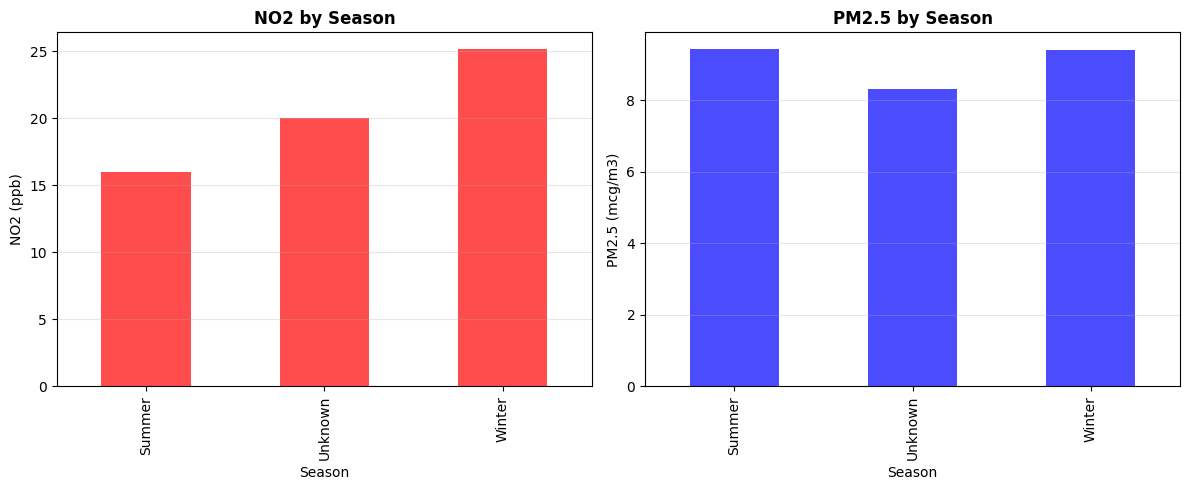

 SEASONAL COMPARISON:
NO2 - Worst season: Winter (25.17)
PM2.5 - Worst season: Summer (9.43)


In [66]:
# Let's Compare NO2 and PM2.5 seasonal patterns
no2_seasonal = df[df["Name"] == "Nitrogen dioxide (NO2)"].groupby("Season")["Data Value"].mean()
pm25_seasonal = df[df["Name"] == "Fine particles (PM 2.5)"].groupby("Season")["Data Value"].mean()

# Let's plot charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

no2_seasonal.plot(kind="bar", ax=ax1, color="red", alpha=0.7)
ax1.set_title("NO2 by Season", fontweight="bold")
ax1.set_ylabel("NO2 (ppb)")
ax1.set_xlabel("Season")
ax1.grid(True, alpha=0.3, axis="y")

pm25_seasonal.plot(kind="bar", ax=ax2, color="blue", alpha=0.7)
ax2.set_title("PM2.5 by Season", fontweight="bold")
ax2.set_ylabel("PM2.5 (mcg/m3)")
ax2.set_xlabel("Season")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Let's print comparison
print(" SEASONAL COMPARISON:")
print(f"NO2 - Worst season: {no2_seasonal.idxmax()} ({no2_seasonal.max():.2f})")
print(f"PM2.5 - Worst season: {pm25_seasonal.idxmax()} ({pm25_seasonal.max():.2f})")

## Is Air Pollution Getting Better or Worse?

In [67]:
# Let's see what Geo Place Name we have again
print(df["Geo Place Name"].unique())

['Chelsea-Village' 'Crown Heights and Prospect Heights (CD8)'
 'Northern SI' 'Brooklyn' 'Highbridge and Concourse (CD4)'
 'Woodside and Sunnyside (CD2)' 'Park Slope and Carroll Gardens (CD6)'
 'Washington Heights and Inwood (CD12)' 'Downtown - Heights - Slope'
 'Canarsie - Flatlands' 'Jamaica' 'Bayside Little Neck-Fresh Meadows'
 'Upper West Side' 'Union Square - Lower East Side'
 'Jamaica and Hollis (CD12)' 'Bensonhurst (CD11)' 'Northeast Bronx'
 'Fresh Meadows' 'Crotona -Tremont'
 'Morningside Heights and Hamilton Heights (CD9)' 'Stapleton - St. George'
 'Morris Park and Bronxdale (CD11)' 'Coney Island (CD13)'
 'Union Square-Lower Manhattan' 'Bedford Stuyvesant - Crown Heights'
 'West Queens' 'Rockaways' 'Borough Park' 'Bensonhurst - Bay Ridge'
 'Central Harlem - Morningside Heights' 'Greenwich Village and Soho (CD2)'
 'Upper East Side (CD8)' 'Parkchester and Soundview (CD9)'
 'Bayside and Little Neck (CD11)' 'Kingsbridge - Riverdale'
 'Ridgewood and Maspeth (CD5)' 'Sunset Park'
 'Re

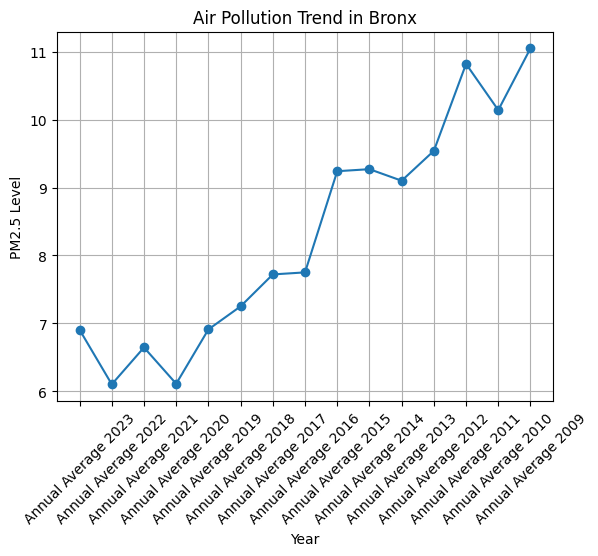

 Year-by-year PM2.5 levels in Bronx:
               Time Period  Data Value
641    Annual Average 2023    6.904677
1503   Annual Average 2022    6.101699
2548   Annual Average 2021    6.644257
3539   Annual Average 2020    6.110000
4827   Annual Average 2019    6.910000
5940   Annual Average 2018    7.250000
6826   Annual Average 2017    7.720000
8395   Annual Average 2016    7.750000
9231   Annual Average 2015    9.240000
10880  Annual Average 2014    9.270000
12008  Annual Average 2013    9.100000
13849  Annual Average 2012    9.540000
14805  Annual Average 2011   10.820000
16045  Annual Average 2010   10.140000
17660  Annual Average 2009   11.050000


In [68]:
# Let's look at Bronx data
bronx = df[df['Geo Place Name'] == 'Bronx']

# PM2.5 data
pm25 = bronx[bronx['Name'] == 'Fine particles (PM 2.5)']

# PM annual averages
annual = pm25[pm25['Time Period'].str.contains('Annual', na=False)]

# Chart
plt.plot(annual['Time Period'], annual['Data Value'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('PM2.5 Level')
plt.title('Air Pollution Trend in Bronx')
plt.grid(True)
plt.show()

# Infos
print(" Year-by-year PM2.5 levels in Bronx:")
print(annual[['Time Period', 'Data Value']])

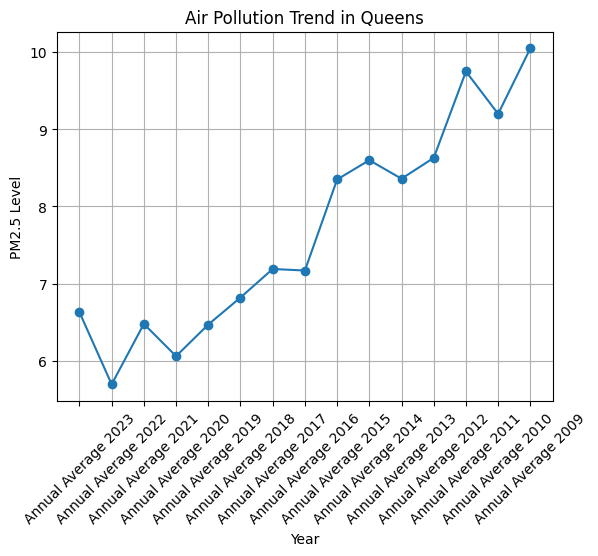

 Year-by-year PM2.5 levels in Queens:
               Time Period  Data Value
685    Annual Average 2023    6.629774
1629   Annual Average 2022    5.695324
2485   Annual Average 2021    6.477947
3572   Annual Average 2020    6.060000
4883   Annual Average 2019    6.470000
5855   Annual Average 2018    6.820000
7042   Annual Average 2017    7.190000
8407   Annual Average 2016    7.170000
9324   Annual Average 2015    8.350000
11113  Annual Average 2014    8.600000
12495  Annual Average 2013    8.360000
13569  Annual Average 2012    8.630000
14731  Annual Average 2011    9.750000
16166  Annual Average 2010    9.200000
17589  Annual Average 2009   10.050000


In [69]:
# Let's look at Queens data
queens = df[df['Geo Place Name'] == 'Queens']

# PM2.5 data
pm25 = queens[queens['Name'] == 'Fine particles (PM 2.5)']

# PM annual averages
annual = pm25[pm25['Time Period'].str.contains('Annual', na=False)]

# Chart
plt.plot(annual['Time Period'], annual['Data Value'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('PM2.5 Level')
plt.title('Air Pollution Trend in Queens')
plt.grid(True)
plt.show()

# Infos
print(" Year-by-year PM2.5 levels in Queens:")
print(annual[['Time Period', 'Data Value']])

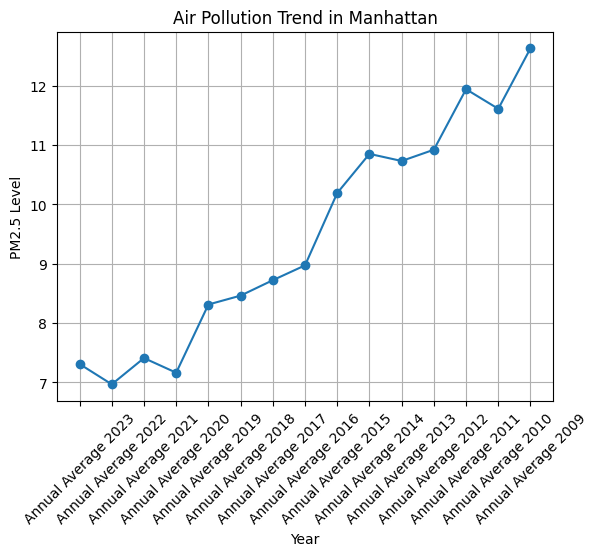

 Year-by-year PM2.5 levels in Manhattan:
               Time Period  Data Value
550    Annual Average 2023    7.306429
1603   Annual Average 2022    6.964430
2575   Annual Average 2021    7.406968
3531   Annual Average 2020    7.160000
4915   Annual Average 2019    8.310000
5705   Annual Average 2018    8.460000
6851   Annual Average 2017    8.720000
8258   Annual Average 2016    8.970000
9331   Annual Average 2015   10.190000
11294  Annual Average 2014   10.850000
12283  Annual Average 2013   10.730000
13716  Annual Average 2012   10.920000
14980  Annual Average 2011   11.940000
16379  Annual Average 2010   11.610000
17854  Annual Average 2009   12.630000


In [70]:
# Let's look at Manhattan data
manhattan = df[df['Geo Place Name'] == 'Manhattan']

# PM2.5 data
pm25 = manhattan[manhattan['Name'] == 'Fine particles (PM 2.5)']

# PM annual averages
annual = pm25[pm25['Time Period'].str.contains('Annual', na=False)]

# Chart
plt.plot(annual['Time Period'], annual['Data Value'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('PM2.5 Level')
plt.title('Air Pollution Trend in Manhattan')
plt.grid(True)
plt.show()

# Infos
print(" Year-by-year PM2.5 levels in Manhattan:")
print(annual[['Time Period', 'Data Value']])

In [71]:
df.to_csv("My_Capstone_Dataset.csv", index=False)